# 🏆 Churn Prediction: Telco Round 2 (V9.0 - ADVANCED OPTIMIZATION)
**Dataset**: [blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Focus**: Tenure Binning + High-Intensity Search (n_iter=15) + Automated Threshold Retrieval (Recall >= 80%).

In [1]:
# 1. Setup & Auth
!pip uninstall umap-learn hdbscan -y -q
!pip install opendatasets mlflow xgboost shap python-dotenv seaborn dagshub scikit-learn==1.5.1 imbalanced-learn -q

import sklearn; print(f"✅ Environment Ready: {sklearn.__version__}")
import os, pandas as pd, numpy as np, mlflow, mlflow.sklearn, matplotlib.pyplot as plt, seaborn as sns, shap, dagshub
import opendatasets as od
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, recall_score, precision_score, make_scorer, precision_recall_curve, f1_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

mlflow.sklearn.autolog(log_models=False)
dagshub.init(repo_owner="nhannhb92", repo_name="msa24-ddm501-group6-final-project", mlflow=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 751.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=48222954-6256-40fc-a813-aa0bc3d9055e&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=6fa4d6ca135a9d6270082e8eefddba3a3387a50625ed6951f1478031be87e7e2




Accessing as nhannhb92

Initialized MLflow to track repo "nhannhb92/msa24-ddm501-group6-final-project"

Repository nhannhb92/msa24-ddm501-group6-final-project initialized!

In [2]:
# 2. Advanced Cleaning (Tenure Binning + Fillna)
def clean_telco_data(df):
    df.columns = [col.lower() for col in df.columns]
    df = df.drop(columns=[c for c in ['customerid'] if c in df.columns])

    # Handle numeric conversion & Fill na instead of drop
    df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
    df['totalcharges'] = df['totalcharges'].fillna(0)

    # --- [Round 2 Upgrade] Tenure Binning ---
    bins = [0, 12, 24, 48, 60, 100]
    labels = ['0-12m', '12-24m', '24-48m', '48-60m', '60m+']
    df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True).astype(str)

    if 'churn' in df.columns:
        df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
    return df

if not os.path.exists("telco-customer-churn"):
    od.download("https://www.kaggle.com/datasets/blastchar/telco-customer-churn")

df_raw = clean_telco_data(pd.read_csv("telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(f"📊 Round 2 Dataset Prepared: {df_raw.shape}")
df_train, df_test = train_test_split(df_raw, test_size=0.2, random_state=42, stratify=df_raw['churn'])


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bchnhnnguynhunh
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


100%|██████████| 172k/172k [00:00<00:00, 535kB/s]



📊 Round 2 Dataset Prepared: (7043, 21)


2026/04/19 16:06:27 INFO mlflow.tracking.fluent: Experiment with name 'Churn_Round2_Colab' does not exist. Creating a new experiment.
2026/04/19 16:06:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
2026/04/19 16:08:56 INFO mlflow.sklearn.utils: Logging the 5 best runs, 10 runs will be omitted.
2026/04/19 16:08:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://w

🏃 View run omniscient-jay-964 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/46b4ab5012cb482e8b363e69eb2eaee7
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run nervous-kite-652 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/675da99659ad404aa05d7d46d6d73936
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run stylish-whale-272 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/78b5ea28933a452d874e45c208b28a7e
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run vaunted-ant-658 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/b0690a6063d5497c9675bbcd98a654cd
🧪 View experiment at: https://dagshu

2026/04/19 16:09:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 16:09:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'CustomerChurnModel_xgboost' already exists. Creating a new version of this model...
2026/04/19 16:09:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CustomerChurnModel_xgboost, version 11
Created version '11' of model 'CustomerChurnModel_xgboost'.


...

Fitting 5 folds for each of 4 candidates, totalling 20 fits


2026/04/19 16:13:25 INFO mlflow.sklearn.utils: Logging the 5 best runs, no runs will be omitted.
2026/04/19 16:13:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


🏃 View run receptive-hound-653 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/fda384f8c4744dbab603ef5451fa85fc
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run intrigued-midge-633 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/96a362fad7e14567bde1bbd231d94ef3
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run sedate-sheep-62 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/0d7a08e2527744d3bbe861892de3f5a0
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19
🏃 View run traveling-auk-817 at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/741599534ca5403ca9cddc536c99a8c7
🧪 View experiment at: https://da

2026/04/19 16:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/19 16:14:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'CustomerChurnModel_logistic_regression' already exists. Creating a new version of this model...
2026/04/19 16:14:16 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CustomerChurnModel_logistic_regression, version 11
Created version '11' of model 'CustomerChurnModel_logistic_regression'.


🏃 View run R2_COLAB_LOGISTIC_REGRESSION at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19/runs/d32d6fe7161840b18a80ac0135e8e658
🧪 View experiment at: https://dagshub.com/nhannhb92/msa24-ddm501-group6-final-project.mlflow/#/experiments/19


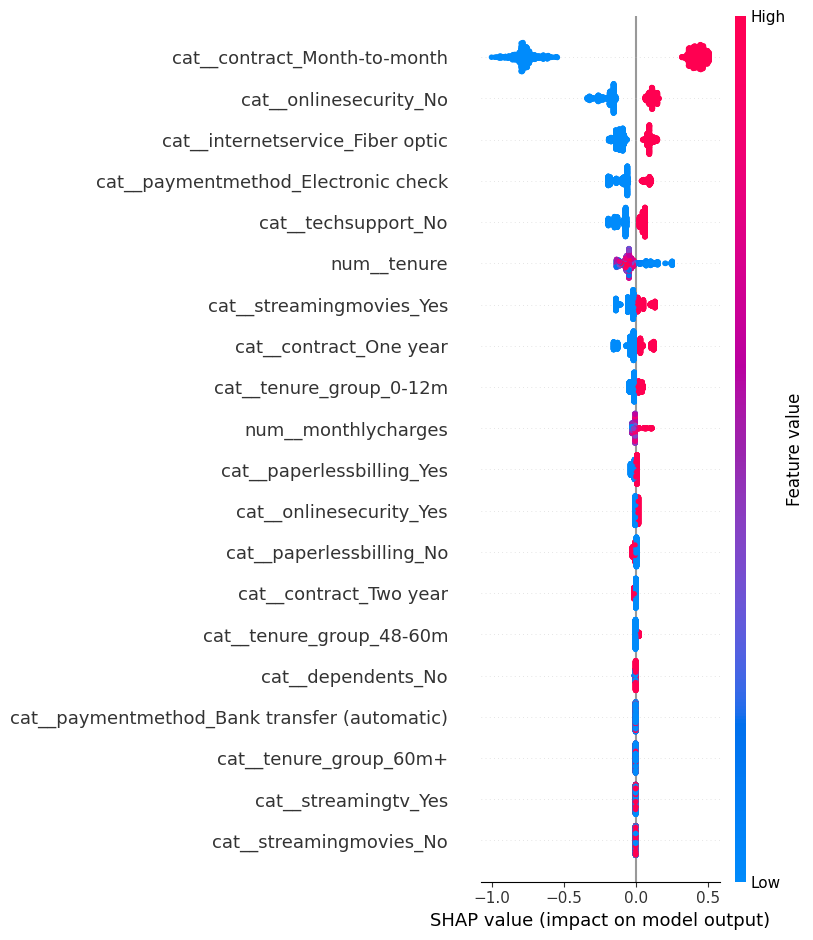

<Figure size 1000x600 with 0 Axes>

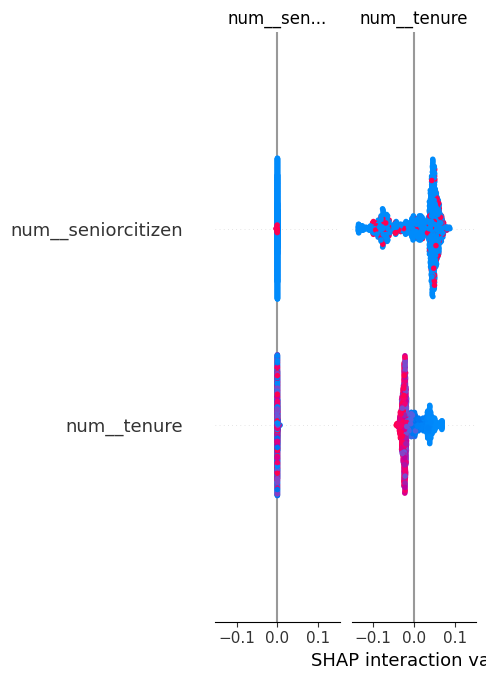

In [3]:
# 3. High Intensity Training Engine (V9.0)
def run_telco_round2(df_tr, df_te, model_type):
    X_tr, y_tr = df_tr.drop(columns=['churn']), df_tr['churn']
    X_te, y_te = df_te.drop(columns=['churn']), df_te['churn']

    num_f = X_tr.select_dtypes(include=[np.number]).columns.tolist()
    cat_f = X_tr.select_dtypes(include=['object']).columns.tolist()

    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_f),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_f)
    ])

    if model_type == "xgboost":
        clf = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42)
        m_p = {
            'clf__max_depth': [3, 4, 5, 6],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__n_estimators': [100, 200, 300]
        }
    elif model_type == "random_forest":
        clf = RandomForestClassifier(random_state=42)
        m_p = {
            'clf__n_estimators': [100, 200, 300],
            'clf__max_depth': [5, 10, 15, None]
        }
    else:
        clf = LogisticRegression(max_iter=2000, random_state=42)
        m_p = {'clf__C': [0.01, 0.1, 1.0, 10.0]}

    mlflow.set_experiment("Churn_Round2_Colab")
    with mlflow.start_run(run_name=f"R2_COLAB_{model_type.upper()}"):
        pipe = ImbPipeline([
            ('pre', pre),
            ('smote', SMOTE(random_state=42)),
            ('clf', clf)
        ])

        # --- [Upgrade 3] High Intensity Search (n_iter=15, cv=5) ---
        search = RandomizedSearchCV(pipe, m_p, n_iter=15, cv=5, scoring='recall', verbose=1)
        search.fit(X_tr, y_tr)
        model = search.best_estimator_

        # --- [Upgrade 2] Automated Threshold Search (Recall >= 80% Optimization) ---
        y_prb = model.predict_proba(X_te)[:, 1]
        precisions, recalls, thresholds = precision_recall_curve(y_te, y_prb)

        best_threshold = 0.5
        valid_idx = [i for i, r in enumerate(recalls[:-1]) if r >= 0.80]
        if valid_idx:
            # Find the index with highest precision among those meeting 80% Recall
            best_sub_idx = valid_idx[0]
            max_p = 0
            for i in valid_idx:
               if precisions[i] > max_p:
                   max_p = precisions[i]
                   best_sub_idx = i
            best_threshold = thresholds[best_sub_idx]

        y_prd = (y_prb >= best_threshold).astype(int)

        print(f"\n🏆 R2 REPORT ({model_type.upper()}) | Threshold: {best_threshold:.4f}")
        print(classification_report(y_te, y_prd))

        mlflow.log_metric("recall", recall_score(y_te, y_prd))
        mlflow.log_metric("precision", precision_score(y_te, y_prd))
        mlflow.log_metric("f1_score", f1_score(y_te, y_prd))
        mlflow.log_param("best_threshold", best_threshold)

        # Fairness Auditing
        audit_df = X_te.copy()
        audit_df['predicted'] = y_prd
        gender_col = next((c for c in audit_df.columns if c.lower() == 'gender'), None)
        if gender_col:
            g_stats = audit_df.groupby(gender_col)['predicted'].mean()
            if len(g_stats) >= 2:
                mlflow.log_metric("bias_gap_gender", abs(g_stats.iloc[0] - g_stats.iloc[1]))

        # SHAP & Model Registration
        try:
            X_t = model.named_steps['pre'].transform(X_te)
            if hasattr(X_t, "toarray"): X_t = X_t.toarray()
            explainer = shap.Explainer(model.named_steps['clf'])
            shap_v = explainer(X_t)
            plt.figure(figsize=(10, 6))
            shap.summary_plot(shap_v, X_t, feature_names=model.named_steps['pre'].get_feature_names_out(), show=False)
            plt.savefig(f"shap_r2_{model_type}.png")
            mlflow.log_artifact(f"shap_r2_{model_type}.png")
        except Exception: pass

        mlflow.sklearn.log_model(model, "model", registered_model_name=f"CustomerChurnModel_{model_type}")

for m in ["xgboost", "random_forest", "logistic_regression"]:
    run_telco_round2(df_train, df_test, m)